In [18]:
N = 500
MAX_THREADS = 16

In [19]:
%%writefile matrix_mul_1d.cpp

#include <iostream>
#include <omp.h>
using namespace std;

#define N 1000

int main(int argc, char* argv[]){

  int threads = atoi(argv[1]);
  omp_set_num_threads(threads);

  static double A[N][N], B[N][N], C[N][N];

  for(int i=0; i<N; i++){
    for(int j=0; j<N; j++){
      A[i][j] = 1.0;
      B[i][j] = 2.0;
      C[i][j] = 0.0;
    }
  }

  double start = omp_get_wtime();

  //1D parallelization

  #pragma omp parallel for
  for(int i =0; i<N; i++){
    for(int j=0; j<N; j++){
      for(int k =0; k<N; k++){
        C[i][j] += A[i][k] * B[k][j];
      }
    }
  }

  double end = omp_get_wtime();

  cout << end - start;
  return 0;
}

Overwriting matrix_mul_1d.cpp


In [20]:
%%writefile matrix_mul_2d.cpp

#include <iostream>
#include <omp.h>
using namespace std;

#define N 1000

int main(int argc, char* argv[]){

  int threads = atoi(argv[1]);
  omp_set_num_threads(threads);

  static double A[N][N], B[N][N], C[N][N];

  for(int i=0; i<N; i++){
    for(int j=0; j<N; j++){
      A[i][j] = 1.0;
      B[i][j] = 2.0;
      C[i][j] = 0.0;
    }
  }


  double start = omp_get_wtime();
  //2D parallelization

  #pragma omp parallel for collapse(2)
  for(int i=0; i<N; i++){
    for(int j=0; j<N; j++){
      for(int k=0; k<N; k++){
        C[i][j] += A[i][k] * B[k][j];
      }
    }
  }

  double end = omp_get_wtime();

  cout << end - start;
  return 0;

}

Overwriting matrix_mul_2d.cpp


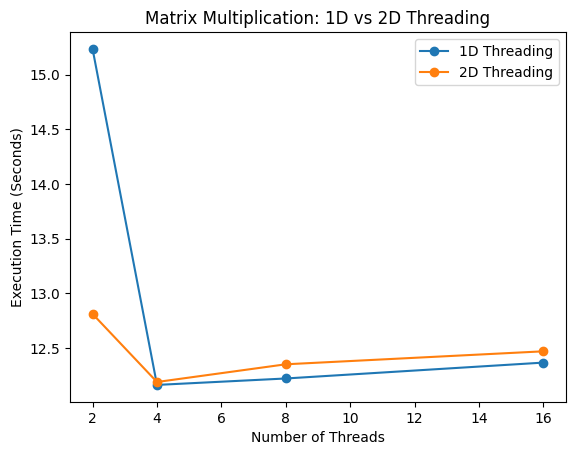

In [21]:
import subprocess
import matplotlib.pyplot as plt

!g++ -fopenmp matrix_mul_1d.cpp -o mat1d
!g++ -fopenmp matrix_mul_2d.cpp -o mat2d

threads = []
time_1d =[]
time_2d =[]

t = 2

while t<=MAX_THREADS:
  t1 = float(subprocess.check_output(["./mat1d", str(t)]).decode().strip());
  t2 = float(subprocess.check_output(["./mat2d", str(t)]).decode().strip());

  threads.append(t)
  time_1d.append(t1)
  time_2d.append(t2)

  t*=2

plt.figure()
plt.plot(threads, time_1d, marker='o', label="1D Threading");
plt.plot(threads, time_2d, marker='o', label="2D Threading");
plt.xlabel("Number of Threads")
plt.ylabel("Execution Time (Seconds)")
plt.title("Matrix Multiplication: 1D vs 2D Threading")
plt.legend()
plt.show()